# Testing for goodness-of-fit using $\chi^2$

---

#### Summary videos

- [Testing for goodness-of-fit using chi square](https://youtu.be/Uk36WGxujkc?si=XzNStucVTtzUxTlD) (15 minutes)

#### Walkthrough videos

- [A test statistic for one-way tables](https://drive.google.com/file/d/1gOeoov8IXnK9BfeCTNkFcnDTlQcbZ8RP/view?usp=sharing) (5 minutes)
- [A hypothesis test using chi-square](https://drive.google.com/file/d/13MA7eaDfWX1vBCpM0K1SK-GWGmJT7NTN/view?usp=sharing) (9 minutes)
- [The chi-square distribution](https://drive.google.com/file/d/1A7oqHt7IrUC3QX6xTK-RmFE-GzcJNDXZ/view?usp=sharing) (10 minutes)
- [Goodness-of-fit](https://drive.google.com/file/d/1UWttK9KVfajqRF1E38HTuXwQG9A09CiC/view?usp=sharing) (11 minutes)

---

## Creating a test statistic for one-way tables

Consider the table below (from page 229 of the textbook) summarizing the racial demographics of a random sample of 275 jurors from a small county along with the proportional breakdown of race for registered voters (the total population of potential jurors).

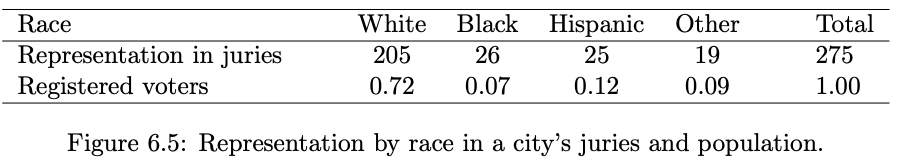

### Question

- Compare the representation of white jurors to the *expected* representation based on the proportion of white registered voters.
- Compare the representation of black jurors to the *expected* representation based on the proportion of black registered voters.
- Compare the representation of hispanic jurors to the *expected* representation based on the proportion of hispanic registered voters.
- Do you think this sample is representative of the population in terms of race?

#### Solution


In [ ]:
expected_white = 0.72 * 275
expected_black = 0.07 * 275
expected_hispanic = 0.12 * 275
expected_other = 0.09 * 275

print(expected_white, expected_black, expected_hispanic, expected_other)

|  | White | Black | Hispanic | Other | Total |
|------|-------|-------|----------|-------|-------|
| Expected representation | 198 | 19.25 | 33 | 24.75 | 275 |
| Observed representation | 205 | 26 | 25 | 19 | 275 |

The last question can be difficult to answer without some way of quantifying how much we should expect the sample proportions to vary from the population proportions. In earlier sections, we studied hypothesis testing for a proportion and a difference of proportions — this situation is different, since we are studying several (i.e. more than two) proportions at once.

### Exercise

We'd like to determine whether there is strong enough evidence to conclude that this sample of jurors is *not* representative of the population. Construct null and alternative hypotheses accordingly.

In our previous hypothesis tests, we used Z-scores to find p-values according to a normal distribution. In cases like the one we're currently in, we use something called the **chi-square test statistic** and the corresponding **chi-square distribution**.

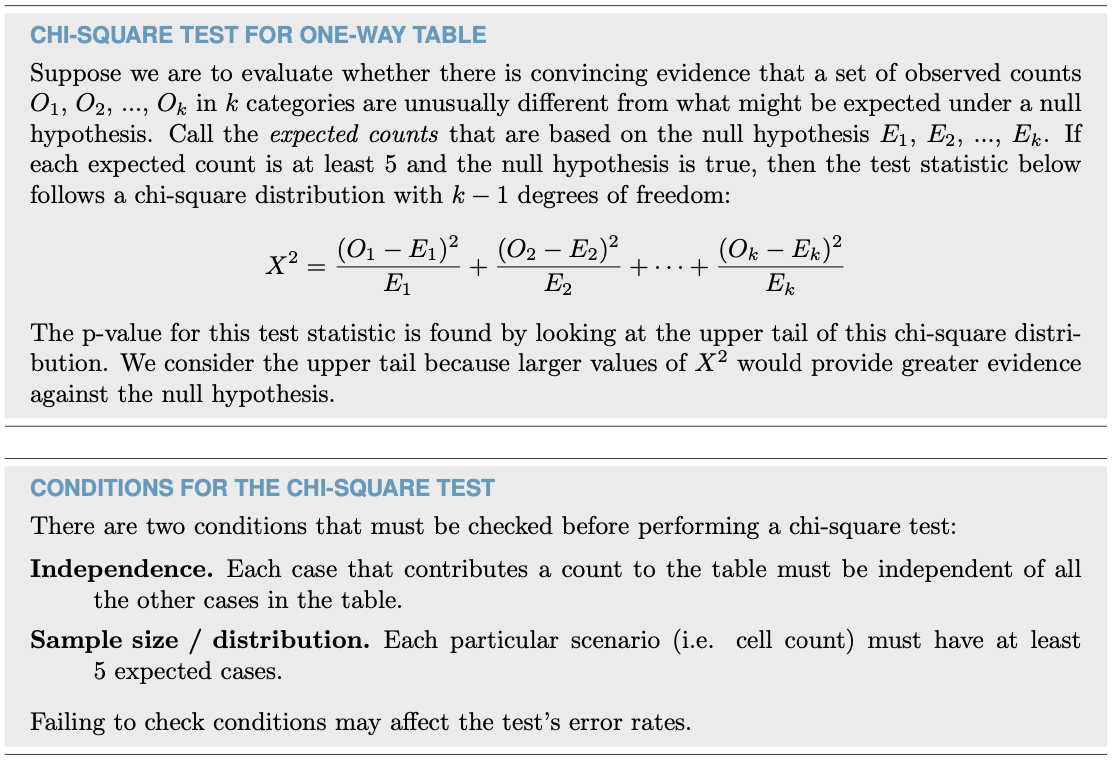

### Example

- Compute $\chi^2$ for the juror sample above.
  - In this case $$\chi^2 = \frac{(205 - 198)^2}{198} + \frac{(26 - 19.25)^2}{19.25} + \frac{(25 - 33)^2}{33} + \frac{(19 - 24.75)^2}{24.75}$$
- How are the terms of $\chi^2$ similar to a Z-score?
- How is $\chi^2$ similar to variance (or standard deviation)?
- Check that the conditions of the chi-square test are met for the juror sample before proceeding.

In [1]:
# Calculate chi-square

(205 - 198)**2/198 + (26 - 19.25)**2/19.25 + (25 - 33)**2/33 + (19 - 24.75)**2/24.75

5.8896103896103895

In [ ]:
# After finding chi-square by hand, run the code below to check your result.

import scipy.stats as stats

observed_counts = [205, 26, 25, 19]
expected_counts = [0.72 * 275, 0.07 * 275, 0.12 * 275, 0.09 * 275]

chi_square_test = stats.chisquare(observed_counts, expected_counts)

print(f"chi-square value: {chi_square_test.statistic}")
print(f"p-value: {chi_square_test.pvalue}")

## The chi-square distribution

The **chi-square distribution** is commonly used to model data that is always positive and typically right-skewed. It depends on a single parameter called the **degrees of freedom (df)**, which is the mean of the distribution.

### Questions

- Use https://www.geogebra.org/classic#probability to visualize a chi-square distribution.
- How do the center, spread, and shape of the distribution change as the degrees of freedom increases?
- What do you think the distribution would look like if the degrees of freedom went to infinity?

When performing a chi-square test on a single categorical variable, we can compute the degrees of freedom of the corresponding distribution as

$$ \fbox{# of levels} - 1. $$

### Example

Let's proceed with a chi-square test to determine whether our juror sample is representative of the population.

- How many levels of the `Race` variable are there?
- How many degrees of freedom should our chi-square distribution have?
- If the null hypothesis is true, we found $\chi^2 = 5.89$. Identify the p-value and draw an appropriate conclusion.

## Evaluating goodness-of-fit for a distribution

We can use chi-square to help us evaluate the difference in *observed* versus *expected* outcomes. A common application of this idea is deciding whether or not a given mathematical model is a good fit for a particular collection of data.

### Question

Is each day's trading activity on the stock market independent of the previous day's activity?

To attempt to answer this question, we can look at data from the S&P500, an index fund tracking the stock performance of the 500 largest companies listed on U.S. stock exchanges. Below is an example of some of this data from page 236 of the textbook, indicating whether each day closed with a net positive (`Up`) or net negative (`D`) change in price.

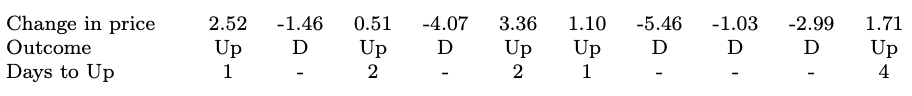

By just examining whether the outcome is `Up` or `D`, we have framed our problem in terms of a **Bernoulli variable**. If the stock market activity is independent from day to day, the number of days before observing an `Up` day should follow a **geometric distribution**.

### Exercise

Construct null and alternative hypothesese that could be used to determine if there is strong enough evidence to conclude that stock market activity is *not* independent from day to day.

Below are some summaries from page 237 of the textbook of the observed number of days until an `Up` along with the *expected* number of days until an `Up` under the null hypothesis (i.e., assuming that the data follows a geometric distribution).

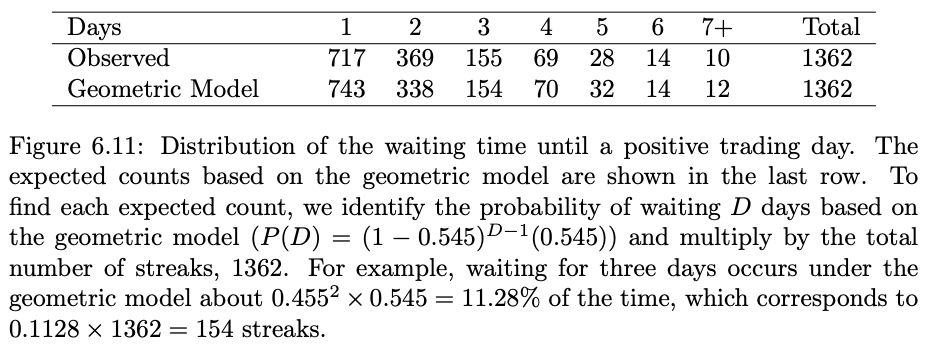

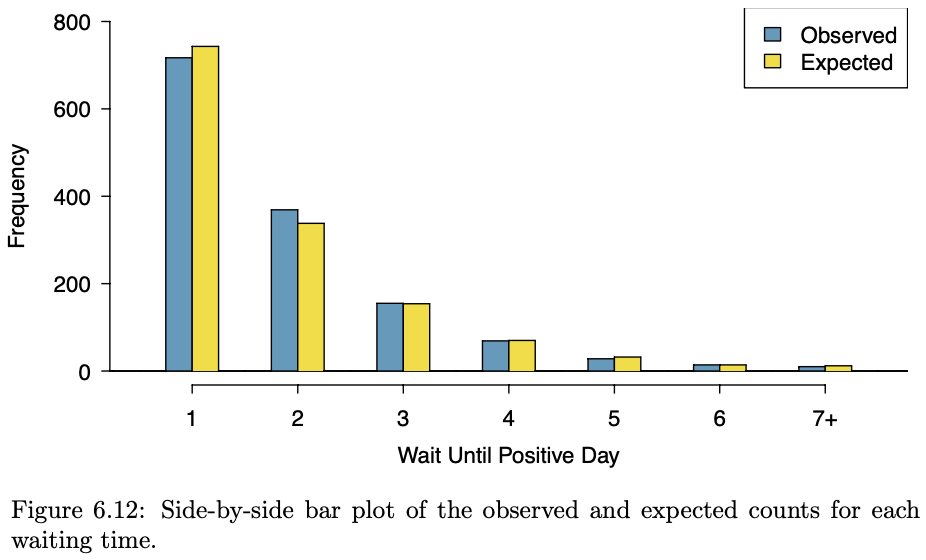

### Example

- Do the deviations from expected to observed appear significant?
- Check that the conditions to use a chi-square test hold.
- Use the table from Figure 6.11 to compute $\chi^2$.
- How many degrees of freedom should our chi-square distribution have?
- Compute a p-value and draw an appropriate conclusion.
- Should we expect the market to be "due" for an `Up` day after several consecutive `D` days?

In [ ]:
# Compute chi-square from the table in Figure 6.11

(717 - 742)**2 / 742 + (369 - 338)**2 / 338 + (155 - 154)**2 / 154 + (69 - 70)**2 / 70 + (28 - 32)**2 / 32 + (14 - 14)**2 / 14 + (10 - 12)**2 / 12

In [ ]:
# Compute chi-square for the stock market data using stats.chisquare

import scipy.stats as stats

observed_counts = [717, 369, 155, 69, 28, 14, 10]
geometric_model_counts = [742, 338, 154, 70, 32, 14, 12] # These are the expected counts.

chi_square_test = stats.chisquare(observed_counts, geometric_model_counts)

print(f"chi-square value: {chi_square_test.statistic}")
print(f"p-value: {chi_square_test.pvalue}")

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.